## Bootstrap
Run the next cell once at the start of each kernel/runtime.

In [1]:
# ============================================================
# BOOTSTRAP: local + Colab CPU
#
# Local: d?ng tr?c ti?p source v? .env trong working tree.
# Colab browser: l?y config t? Colab Secrets.
# VS Code ? Colab CPU: d?n m?t COLAB_RUNTIME_CONFIG_B64 bundle duy nh?t.
# ============================================================
from __future__ import annotations

import base64
import binascii
import json
import os
import subprocess
import sys
from getpass import getpass
from pathlib import Path

from dotenv import load_dotenv

REPO_OWNER = "lbngyn"
REPO_NAME = "Santander-Product-Recommendation"
REPO_BRANCH = "feat/colab-local-run"
REPO_URL = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
RUNTIME_CONFIG_KEYS = (
    "GITHUB_TOKEN",
    "GCP_SERVICE_ACCOUNT_JSON",
    "GOOGLE_CLOUD_PROJECT",
    "GCS_BUCKET",
    "GCS_RAW_PREFIX",
    "GCS_CHECKPOINT_PREFIX",
)


def is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError("Cannot find project root containing src/ and requirements.txt.")


def run_git(arguments: list[str], token: str) -> None:
    credentials = base64.b64encode(f"x-access-token:{token}".encode()).decode()
    command = ["git", "-c", f"http.https://github.com/.extraheader=AUTHORIZATION: basic {credentials}", *arguments]
    subprocess.run(command, check=True)


def decode_runtime_bundle(encoded_value: str) -> dict[str, str]:
    try:
        payload = base64.b64decode(encoded_value, validate=True).decode("utf-8")
        config = json.loads(payload)
    except (binascii.Error, UnicodeDecodeError, json.JSONDecodeError) as error:
        raise ValueError("COLAB_RUNTIME_CONFIG_B64 must be a Base64-encoded JSON object.") from error
    missing = [key for key in RUNTIME_CONFIG_KEYS if not config.get(key)]
    if missing:
        raise ValueError(f"Runtime config bundle is missing: {', '.join(missing)}")
    if isinstance(config["GCP_SERVICE_ACCOUNT_JSON"], dict):
        config["GCP_SERVICE_ACCOUNT_JSON"] = json.dumps(config["GCP_SERVICE_ACCOUNT_JSON"])
    return {key: str(config[key]) for key in RUNTIME_CONFIG_KEYS}


def load_colab_ui_secrets() -> dict[str, str] | None:
    """Return secrets only when this kernel runs through the Colab browser UI."""
    try:
        from google.colab import userdata
        github_token = userdata.get("GITHUB_TOKEN")
        if not github_token:
            return None
        config = {"GITHUB_TOKEN": github_token}
        for key in RUNTIME_CONFIG_KEYS[1:]:
            value = userdata.get(key)
            if not value:
                raise RuntimeError(f"Missing Colab Secret: {key}")
            config[key] = value
        return config
    except Exception:
        return None


def load_colab_runtime_config() -> dict[str, str]:
    """Use browser Secrets, env bundle, or one secure runtime prompt."""
    ui_config = load_colab_ui_secrets()
    if ui_config:
        print("Using Colab Secrets.")
        return ui_config

    encoded_value = os.getenv("COLAB_RUNTIME_CONFIG_B64")
    if not encoded_value:
        encoded_value = getpass("Paste COLAB_RUNTIME_CONFIG_B64 once (runtime-only): ")
    return decode_runtime_bundle(encoded_value)


IS_COLAB = is_colab_runtime()
ENV = "colab" if IS_COLAB else "local"
os.environ["SANTANDER_RUNTIME"] = ENV

if IS_COLAB:
    runtime_config = load_colab_runtime_config()
    os.environ.update(runtime_config)
    github_token = runtime_config["GITHUB_TOKEN"]
    PROJECT_ROOT = Path("/content") / REPO_NAME

    if not PROJECT_ROOT.exists():
        print("Cloning source to Colab fast disk...")
        run_git(["clone", "--branch", REPO_BRANCH, "--single-branch", REPO_URL, str(PROJECT_ROOT)], github_token)
    else:
        print("Syncing latest source to Colab fast disk...")
        run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", REPO_BRANCH], github_token)
        run_git(["-C", str(PROJECT_ROOT), "checkout", REPO_BRANCH], github_token)
        run_git(["-C", str(PROJECT_ROOT), "pull", "--ff-only", "origin", REPO_BRANCH], github_token)

    requirements_path = PROJECT_ROOT / "requirements.txt"
    if not requirements_path.is_file():
        raise FileNotFoundError(f"requirements.txt is missing from branch {REPO_BRANCH}.")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)], check=True)

    # Persist raw CSV and Parquet checkpoints between Colab runtimes.
    from google.colab import drive
    drive_mount = Path("/content/drive")
    if not (drive_mount / "MyDrive").exists():
        drive.mount(str(drive_mount))
    DATA_ROOT = drive_mount / "MyDrive/projects/santander/data"
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    load_dotenv(PROJECT_ROOT / ".env")
    DATA_ROOT = Path(os.getenv("SANTANDER_DATA_ROOT", PROJECT_ROOT / "data"))

os.environ["SANTANDER_DATA_ROOT"] = str(DATA_ROOT)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Notebook ready | environment={ENV} | source={PROJECT_ROOT}")


Mounted at /content/drive
Notebook ready | environment=colab | source=/content/Santander-Product-Recommendation


In [2]:
# COLAB SOURCE UPDATE
# 1) Tr?n local: git add/commit/push source m?i l?n REPO_BRANCH.
# 2) Tr?n Colab: ch?y cell n?y, sau ?? ch?y l?i c?c cell import/EDA c?n d?ng code m?i.

if not IS_COLAB:
    print("Local environment: source is already current; no Colab sync is needed.")
else:
    status = subprocess.run(
        ["git", "-C", str(PROJECT_ROOT), "status", "--porcelain"],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
    if status:
        raise RuntimeError(
            "The Colab source copy has uncommitted changes. Do not overwrite it; "
            "restart the runtime or resolve those changes first."
        )

    run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "checkout", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "pull", "--ff-only", "origin", REPO_BRANCH], github_token)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_ROOT / "requirements.txt")],
        check=True,
    )

    import importlib
    importlib.invalidate_caches()
    stale_modules = [name for name in sys.modules if name == "src" or name.startswith("src.")]
    for name in stale_modules:
        del sys.modules[name]
    print(f"Colab source updated from {REPO_BRANCH}; cleared {len(stale_modules)} cached src modules. Re-run the import/config cell, then the desired EDA cells.")


Colab source updated from feat/colab-local-run; cleared 0 cached src modules. Re-run the import/config cell, then the desired EDA cells.


# Start Ingest

In [3]:
from src.data.ingest import config_from_environment, run_default_ingests

INGEST_CONFIG = config_from_environment()


In [4]:
ingest_results = run_default_ingests(
    config=INGEST_CONFIG,
    # force_rebuild=True,
)
ingest_results

[ingest] Reusing local raw file: /content/drive/MyDrive/projects/santander/data/raw/train_ver2.csv
[ingest] Reusing local checkpoint: /content/drive/MyDrive/projects/santander/data/interim/train.parquet
[ingest] Upload skipped: raw file was reused and skip_upload=True.
[ingest] Reusing local raw file: /content/drive/MyDrive/projects/santander/data/raw/test_ver2.csv
[ingest] Reusing local checkpoint: /content/drive/MyDrive/projects/santander/data/interim/test.parquet
[ingest] Upload skipped: raw file was reused and skip_upload=True.


{'train_ver2.csv': {'downloaded_file': None,
  'checkpoint_rebuilt': False,
  'rows': None,
  'checkpoint': '/content/drive/MyDrive/projects/santander/data/interim/train.parquet',
  'checkpoint_uri': None},
 'test_ver2.csv': {'downloaded_file': None,
  'checkpoint_rebuilt': False,
  'rows': None,
  'checkpoint': '/content/drive/MyDrive/projects/santander/data/interim/test.parquet',
  'checkpoint_uri': None}}

# EDA

## EDA setup
Create a disk-backed DuckDB connection and reusable helpers. Queries scan Parquet directly; only aggregates and bounded samples are returned to pandas.

In [5]:
from __future__ import annotations

import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

# Vị trí data mà duckdb sẽ dùng để đọc các file tạm thời
TRAIN_PARQUET = INGEST_CONFIG.checkpoint_dir / 'train.parquet'
TEST_PARQUET = INGEST_CONFIG.checkpoint_dir / 'test.parquet'
if not TRAIN_PARQUET.is_file():
    raise FileNotFoundError(f'Missing checkpoint: {TRAIN_PARQUET}. Run ingestion first.')

# Nơi duckdb lưu trữ các file tạm thời, có thể override bằng biến môi trường DUCKDB_TEMP_DIRECTORY
DUCKDB_TEMP_DIR = Path(os.getenv('DUCKDB_TEMP_DIRECTORY', Path(os.getenv('SANTANDER_WORK_ROOT', 'data')) / 'duckdb_temp'))
DUCKDB_TEMP_DIR.mkdir(parents=True, exist_ok=True)
con = duckdb.connect(database=':memory:')
con.execute(f"SET temp_directory = '{str(DUCKDB_TEMP_DIR).replace(chr(39), chr(39) * 2)}'")
con.execute("SET memory_limit = '2GB'" if ENV == 'local' else "SET memory_limit = '8GB'")

def q(sql: str, *params: object) -> pd.DataFrame:
    """Run an out-of-core DuckDB query and materialize only its result."""
    return con.execute(sql, list(params)).df()

def quote_identifier(name: str) -> str:
    return '"' + name.replace('"', '""') + '"'

def scan(path: Path) -> str:
    return 'read_parquet(?)'

TRAIN_COLUMNS = q('DESCRIBE SELECT * FROM read_parquet(?)', str(TRAIN_PARQUET))
TEST_COLUMNS = q('DESCRIBE SELECT * FROM read_parquet(?)', str(TEST_PARQUET)) if TEST_PARQUET.is_file() else None
ALL_COLUMNS = TRAIN_COLUMNS['column_name'].tolist()
PRODUCT_COLUMNS = [column for column in ALL_COLUMNS if column.endswith('_ult1')]
DATE_COLUMNS = [column for column in ALL_COLUMNS if column.startswith('fecha_') or column == 'ult_fec_cli_1t']
# NUMERIC_COLUMNS = [column for column in ['ncodpers', 'age', 'antiguedad', 'renta'] if column in ALL_COLUMNS]
# CATEGORICAL_COLUMNS = [column for column in ALL_COLUMNS if column not in set(NUMERIC_COLUMNS + DATE_COLUMNS + PRODUCT_COLUMNS)]
EDA_SAMPLE_ROWS = 10
EDA_TOP_N = 15
EDA_PLOT_SAMPLE_ROWS = 200_000


In [6]:
PRODUCT_CATALOG = {
    "ind_ahor_fin_ult1": "Tài khoản tiết kiệm", "ind_aval_fin_ult1": "Bảo lãnh tài chính",
    "ind_cco_fin_ult1": "Tài khoản thanh toán", "ind_cder_fin_ult1": "Tài khoản phái sinh",
    "ind_cno_fin_ult1": "Tài khoản trả lương", "ind_ctju_fin_ult1": "Tài khoản trẻ em",
    "ind_ctma_fin_ult1": "Tài khoản Más Particular", "ind_ctop_fin_ult1": "Tài khoản cá nhân",
    "ind_ctpp_fin_ult1": "Tài khoản cá nhân Plus", "ind_deco_fin_ult1": "Tiền gửi ngắn hạn",
    "ind_deme_fin_ult1": "Tiền gửi trung hạn", "ind_dela_fin_ult1": "Tiền gửi dài hạn",
    "ind_ecue_fin_ult1": "Tài khoản điện tử (e-Account)", "ind_fond_fin_ult1": "Quỹ đầu tư",
    "ind_hip_fin_ult1": "Vay thế chấp / Bất động sản", "ind_plan_fin_ult1": "Kế hoạch hưu trí",
    "ind_pres_fin_ult1": "Vay tiêu dùng", "ind_reca_fin_ult1": "Thanh toán thuế",
    "ind_tjcr_fin_ult1": "Thẻ tín dụng", "ind_valo_fin_ult1": "Chứng khoán",
    "ind_viv_fin_ult1": "Tài khoản mua nhà", "ind_nomina_ult1": "Thu nhập từ lương",
    "ind_nom_pens_ult1": "Thu nhập hưu trí", "ind_recibo_ult1": "Trích nợ tự động"
}

COLUMN_DESCRIPTIONS = {
    "fecha_dato": "Ngày snapshot dữ liệu hàng tháng",
    "ncodpers": "Mã định danh khách hàng (Customer ID)",
    "ind_empleado": "Chỉ số nhân viên ngân hàng (A/B/F/N)",
    "pais_residencia": "Quốc gia cư trú",
    "sexo": "Giới tính khách hàng (H: Nam, V: Nữ)",
    "age": "Tuổi khách hàng",
    "fecha_alta": "Ngày gia nhập ngân hàng lần đầu",
    "ind_nuevo": "Cờ khách hàng mới trong 6 tháng gần nhất (1: Mới, 0: Cũ)",
    "antiguedad": "Thâm niên gắn kết với ngân hàng (tháng)",
    "indrel": "Trạng thái khách hàng chính (1: Primary, 99: Primary end of month)",
    "ult_fec_cli_1t": "Ngày cuối cùng là khách hàng chính",
    "indrel_1mes": "Loại khách hàng đầu tháng (1/2/3/4/P)",
    "tiprel_1mes": "Loại quan hệ khách hàng đầu tháng (A: Active, I: Inactive, P: Former, R: Potential)",
    "indresi": "Cờ cư trú trong nước (S: Có, N: Không)",
    "indext": "Cờ khách hàng nước ngoài (S: Có, N: Không)",
    "conyuemp": "Cờ vợ/chồng là nhân viên ngân hàng",
    "canal_entrada": "Kênh gia nhập ngân hàng",
    "indfall": "Cờ đã qua đời (S: Có, N: Không)",
    "tipodom": "Loại địa chỉ (1: Địa chỉ chính)",
    "cod_prov": "Mã tỉnh/thành phố cư trú",
    "nomprov": "Tên tỉnh/thành phố cư trú",
    "ind_actividad_cliente": "Cờ hoạt động của khách hàng (1: Active, 0: Inactive)",
    "renta": "Thu nhập gộp hàng năm của gia đình (EUR)",
    "segmento": "Phân đoạn khách hàng (01-VIP, 02-Individuals, 03-College)"
}

COLUMN_DESCRIPTIONS.update(PRODUCT_CATALOG)

## 1. Structure
Establish the size, a bounded sample, split sizes, and the likely grain of a row without loading either dataset into memory.

In [7]:
# Kích thước của data
structure = q('SELECT COUNT(*) AS train_rows FROM read_parquet(?)', str(TRAIN_PARQUET))

structure['train_columns'] = len(ALL_COLUMNS)
if TEST_COLUMNS is not None:
    structure['test_rows'] = q('SELECT COUNT(*) FROM read_parquet(?)', str(TEST_PARQUET)).iloc[0, 0]
    structure['test_columns'] = len(TEST_COLUMNS)
display(structure)

,train_rows,train_columns,test_rows,test_columns
0,13647309,48,929615,24


In [8]:
# head(10), xem một số sample của data
display(q(f'SELECT * FROM read_parquet(?) LIMIT {EDA_SAMPLE_ROWS}', str(TRAIN_PARQUET)))

,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2015-01-28,1375586,N,ES,H,35.0,2015-01-12,0,6,1,...,0,0,0,0,0,0,0,0,0,0
1,2015-01-28,1050611,N,ES,V,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
2,2015-01-28,1050612,N,ES,V,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
3,2015-01-28,1050613,N,ES,H,22.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
4,2015-01-28,1050614,N,ES,V,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
5,2015-01-28,1050615,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
6,2015-01-28,1050616,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
7,2015-01-28,1050617,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
8,2015-01-28,1050619,N,ES,H,24.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
9,2015-01-28,1050620,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0


In [9]:
if {'ncodpers', 'fecha_dato'}.issubset(ALL_COLUMNS):
    grain = q('''
        SELECT
            COUNT(*) AS rows,
            COUNT(DISTINCT ncodpers) AS customers,
            COUNT(DISTINCT (ncodpers, fecha_dato)) AS customer_date_pairs,
            MIN(fecha_dato) AS first_snapshot,
            MAX(fecha_dato) AS last_snapshot
        FROM read_parquet(?)
    ''', str(TRAIN_PARQUET))
    display(grain)
    print('Likely row grain: one customer (ncodpers) observed at one monthly fecha_dato snapshot; confirm from customer_date_pairs versus rows.')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,customers,customer_date_pairs,first_snapshot,last_snapshot
0,13647309,956645,13647309,2015-01-28,2016-05-28


Likely row grain: one customer (ncodpers) observed at one monthly fecha_dato snapshot; confirm from customer_date_pairs versus rows.


- số cặp customer_date_pair unique = số rows của data -> data k bị duplicate
- số customer > số lượng sample trong testset -> không phải mọi customer trong trainset đều sẽ xuất hiện trong testset và cần dự đoán. 

## 2. Schema and semantics
Document physical types, distinct counts, representative values, and a conservative semantic-type hypothesis for every train feature.

In [10]:
def semantic_type(column: str, duckdb_type: str, n_unique: int, n_rows: int) -> str:
    """
    Infer semantic type using simple rule-based heuristics.

    Possible outputs:
    - target
    - identifier
    - numerical
    - categorical
    - ordinal
    - boolean
    - datetime
    - text
    """

    dtype = duckdb_type.upper()
    unique_ratio = n_unique / n_rows if n_rows > 0 else 0

    # 1. Product columns are predefined targets
    if column in PRODUCT_COLUMNS: return "target"

    # 2. Datetime
    if "DATE" in dtype or "TIMESTAMP" in dtype: return "datetime"

    # 3. Boolean
    if "BOOLEAN" in dtype: return "boolean"

    if n_unique == 2: return "boolean"

    # 4. Numeric types
    is_numeric = any(
        type_name in dtype
        for type_name in ["TINYINT", "SMALLINT", "INTEGER", "BIGINT", "HUGEINT", "FLOAT", "DOUBLE", "DECIMAL", "REAL"]
    )

    if is_numeric:
        # Almost every value is unique -> likely identifier
        if unique_ratio > 0.90: return "identifier"

        # Small discrete numeric domain -> ordinal candidate
        if n_unique <= 10:
            return "ordinal"
        return "numerical"

    # 5. String types
    is_string = any(
        type_name in dtype
        for type_name in ["VARCHAR", "CHAR", "TEXT"]
    )

    if is_string:
        # Almost every value is unique -> identifier/text candidate
        if unique_ratio > 0.90:
            return "identifier"

        return "categorical"

    # Fallback
    return "categorical"

# 1. Get exact number of rows
n_rows = q("SELECT COUNT(*) AS n_rows FROM read_parquet(?)", str(TRAIN_PARQUET), ).iloc[0]["n_rows"]

# 2. Exact unique count for every column
distinct_sql = ", ".join(f"COUNT(DISTINCT {quote_identifier(c)}) AS {quote_identifier(c)}" for c in ALL_COLUMNS)

distinct_counts = (
    q(
        f"SELECT {distinct_sql} FROM read_parquet(?)",
        str(TRAIN_PARQUET),
    )
    .T
    .rename(columns={0: "n_unique"})
)

distinct_counts.index.name = "column_name"

# 3. Build schema report
schema_report = (
    TRAIN_COLUMNS[["column_name", "column_type"]]
    .merge(
        distinct_counts.reset_index(),
        on="column_name",
        how="left",
    )
)

# 4. Infer semantic type
schema_report["semantic_type"] = [
    semantic_type(
        column=c,
        duckdb_type=t,
        n_unique=n,
        n_rows=n_rows,
    )
    for c, t, n in zip(
        schema_report["column_name"],
        schema_report["column_type"],
        schema_report["n_unique"],
    )
]

# 5. Placeholder for sample / unique values
def get_sample_values(column: str, semantic_type: str, n_unique: int, sample_size: int = 10):
    col = quote_identifier(column)
    limit = "" if semantic_type == "categorical" and n_unique < 10 else f"LIMIT {sample_size}"
    sql = f"SELECT DISTINCT {col} FROM read_parquet(?) WHERE {col} IS NOT NULL ORDER BY {col} {limit}"
    values = q(sql, str(TRAIN_PARQUET)).iloc[:, 0].tolist()

    if semantic_type == "datetime":
        values = [pd.Timestamp(v).strftime("%Y-%m-%d") for v in values]

    return values

schema_report["sample_values"] = [
    get_sample_values(row.column_name, row.semantic_type, row.n_unique)
    for row in schema_report.itertuples()
]

# Thêm mô tả cho từng feature để có thể thu được insight tốt hơn
schema_report["description"] = schema_report["column_name"].map(COLUMN_DESCRIPTIONS).fillna("Chưa có mô tả")

display(schema_report)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,n_unique,semantic_type,sample_values,description
0,fecha_dato,TIMESTAMP_NS,17,datetime,"[2015-01-28, 2015-02-28, 2015-03-28, 2015-04-2...",Ngày snapshot dữ liệu hàng tháng
1,ncodpers,BIGINT,956645,numerical,"[15889, 15890, 15891, 15892, 15893, 15894, 158...",Mã định danh khách hàng (Customer ID)
2,ind_empleado,VARCHAR,5,categorical,"[A, B, F, N, S]",Chỉ số nhân viên ngân hàng (A/B/F/N)
3,pais_residencia,VARCHAR,118,categorical,"[AD, AE, AL, AO, AR, AT, AU, BA, BE, BG]",Quốc gia cư trú
4,sexo,VARCHAR,2,boolean,"[H, V]","Giới tính khách hàng (H: Nam, V: Nữ)"
5,age,FLOAT,120,numerical,"[2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,...",Tuổi khách hàng
6,fecha_alta,TIMESTAMP_NS,6756,datetime,"[1995-01-16, 1995-01-17, 1995-01-23, 1995-01-3...",Ngày gia nhập ngân hàng lần đầu
7,ind_nuevo,BIGINT,2,boolean,"[0, 1]",Cờ khách hàng mới trong 6 tháng gần nhất (1: M...
8,antiguedad,BIGINT,258,numerical,"[-999999, 0, 1, 2, 3, 4, 5, 6, 7, 8]",Thâm niên gắn kết với ngân hàng (tháng)
9,indrel,BIGINT,2,boolean,"[1, 99]","Trạng thái khách hàng chính (1: Primary, 99: P..."


- `fecha_dato`: chỉ có 17 giá trị, tương ứng 2015-01-28 -> 2016-05-28 -> không có anomaly trong này, việc còn lại là kiểm tra tính liên tục của dữ liệu theo customer_id. 
- `ncodpers`: khóa này cùng với fecha_dato sẽ tạo nên một cặp giá trị sử dụng làm key trong dataset này (ở trên đã ensure là không bị duplicate `customer_date_pairs`)
- `age`: 120 giá trị -> có thể chứa anomaly, ngoài ra thì có một số khách hàng mới chỉ 2,3 tuổi hơi vô lý.
- `antiguedad`: thâm niên nhưng lại có giá trị âm, ngoài ra kiểm tra xem nó có correlate với 2 cột `fecha_alta` và `ult_fec_cli_1t` lần lượt là ngày gia nhập ngân hàng và ngày cuối cùng là khách hàng, có thể dùng để fill null. 
- `indrel`: Chuyển về dạng boolean nhãn 0/1
- `indrel_1mes`: chuẩn hóa lại các giá trị, hiện tại đang là VARCHAR và nhận hai giá trị 1 và 1.0 là khác nhau,... và kiểm tra tính ordinal của feature này.
- `tipodom`: feature chỉ có 1 loại giá trị duy nhất, kiểm tra xem tỉ lệ null là bao nhiêu, và nguyên nhân null, có thể fill null là một giá trị nào đó cụ thể hay không?
- `cod_prov` và `nomprov`: bị duplicate có thể dùng để fill null cho nhau và phải chuẩn hóa lại, không nên để là số BIGINT tại vì mã tỉnh thành phố thì không có thứ tự (ngoài ra có thể kiểm tra, check valid khi so sánh với mã quốc gia). 
- `renta`: kiểm tra có giá trị âm không?  
- `segmento`: chuẩn hóa lại giá trị, có thể là sẽ có tính oridnal.

## 3. Data quality
Measure missingness and duplicates, then surface simple invalid numeric ranges and category-label inconsistencies using aggregate queries.

### Xem missing value của các cột liên quan tới thông tin cá nhân của người dùng


In [11]:
total_rows = int(structure.loc[0, "train_rows"])

null_sql = ", ".join(
    f"SUM({quote_identifier(c)} IS NULL) AS {quote_identifier(c)}"
    for c in ALL_COLUMNS
)

null_report = q(
    f"SELECT {null_sql} FROM read_parquet(?)",
    str(TRAIN_PARQUET)
).T.rename(columns={0: "null_count"})

null_report.index.name = "column_name"
null_report["null_ratio"] = null_report["null_count"] / total_rows
null_report["description"] = null_report.index.map(COLUMN_DESCRIPTIONS)

product_null_report = null_report.loc[null_report.index.isin(PRODUCT_COLUMNS)].sort_values("null_ratio", ascending=False)
profile_null_report = null_report.loc[~null_report.index.isin(PRODUCT_COLUMNS)].sort_values("null_ratio", ascending=False)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [12]:
display(profile_null_report)

,null_count,null_ratio,description
column_name,,,
conyuemp,13645501.0,0.999868,Cờ vợ/chồng là nhân viên ngân hàng
ult_fec_cli_1t,13622516.0,0.998183,Ngày cuối cùng là khách hàng chính
renta,2794375.0,0.204756,Thu nhập gộp hàng năm của gia đình (EUR)
segmento,189368.0,0.013876,"Phân đoạn khách hàng (01-VIP, 02-Individuals, ..."
canal_entrada,186126.0,0.013638,Kênh gia nhập ngân hàng
tiprel_1mes,149781.0,0.010975,"Loại quan hệ khách hàng đầu tháng (A: Active, ..."
indrel_1mes,149781.0,0.010975,Loại khách hàng đầu tháng (1/2/3/4/P)
cod_prov,93591.0,0.006858,Mã tỉnh/thành phố cư trú
nomprov,93591.0,0.006858,Tên tỉnh/thành phố cư trú


- `conyuemp`:cần phân tích thêm, xem feature này có correlate với các feature liên quan tới nhân viên ngân hàng không như là cột `ind_empleado`
- `ult_fec_cli_1t`: tỉ lệ null cao do có thể khách hàng đang trong tình trạng là khách hàng chính hoặc chưa từng là khách hàng chính, kiểm tra correlation của cột này với các cột như là `ind_nuevo`, `indrel`.
- `indfall` là cờ đánh  dấu khách hàng đã qua đời, điều đáng chú ý là có nhiều feature khác cũng được ghi nhận là có cùng số lượng null và null ratio bằng với `indfall` -> có thể là missing data đến từ việc khách hàng đã qua đời và trạng thái ngừng hoạt động, không có thêm record. -> tìm ra các khách hàng cụ thể và có chiến lược fill null đúng cho các customer này. 
- Các trường thông tin missing khác có thể fill null dựa trên các record của các tháng trước của cùng customer (trừ các cột có tính cập nhật dữ liệu như `tiprel_1mes`, `indrel_1mes`). Hoặc không thì có thể tạo category mới là UNKNOW (với categorical), các cột numeric cần xem xét thêm. 

### Xem missing value của các cột liên quan tới lịch sử sản phẩm của người dùng


In [13]:
display(product_null_report)

,null_count,null_ratio,description
column_name,,,
ind_nom_pens_ult1,16063.0,0.001177,Thu nhập hưu trí
ind_nomina_ult1,16063.0,0.001177,Thu nhập từ lương
ind_ahor_fin_ult1,0.0,0.000000,Tài khoản tiết kiệm
ind_aval_fin_ult1,0.0,0.000000,Bảo lãnh tài chính
ind_cno_fin_ult1,0.0,0.000000,Tài khoản trả lương
ind_ctju_fin_ult1,0.0,0.000000,Tài khoản trẻ em
ind_cco_fin_ult1,0.0,0.000000,Tài khoản thanh toán
ind_cder_fin_ult1,0.0,0.000000,Tài khoản phái sinh
ind_ctop_fin_ult1,0.0,0.000000,Tài khoản cá nhân


- Hai cột bị missing có cùng tỉ lệ và số lượng -> kiểm tra xem có đồng thời thiếu không? 
- `ind_nom_pens_ult1` liên quan tới người cao tuổi (đã nghỉ hưu) nên là có thể liên quan tới cột `indfall`
- Không nên tự ý fill null là 0 hay 1 vì có thể làm loạn, gây sai các thông tin liên quan tới thêm/bỏ sản phẩm. 

### Kiểm tra duplicate rows và duplicate keys (ncodpers, fecha_dato)


In [14]:
all_columns_sql = ', '.join(quote_identifier(c) for c in ALL_COLUMNS)
duplicate_rows = q(f'''
    SELECT COALESCE(SUM(group_rows - 1), 0) AS duplicate_row_count
    FROM (
        SELECT COUNT(*) AS group_rows
        FROM read_parquet(?)
        GROUP BY {all_columns_sql}
        HAVING COUNT(*) > 1
    )
''', str(TRAIN_PARQUET))
display(duplicate_rows)

if {'ncodpers', 'fecha_dato'}.issubset(ALL_COLUMNS):
    duplicate_keys = q('''
        SELECT COUNT(*) - COUNT(DISTINCT (ncodpers, fecha_dato)) AS duplicate_customer_date_keys
        FROM read_parquet(?)
    ''', str(TRAIN_PARQUET))
    display(duplicate_keys)



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_row_count
0,0.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_customer_date_keys
0,0


- Không có duplicate của data này

## 4. Products columns EDA

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_column,customer_count,product,ratio
2,ind_cco_fin_ult1,562259.0,Tài khoản thanh toán,58.77
23,ind_recibo_ult1,113602.0,Trích nợ tự động,11.88
7,ind_ctop_fin_ult1,100658.0,Tài khoản cá nhân,10.52
12,ind_ecue_fin_ult1,75946.0,Tài khoản điện tử (e-Account),7.94
4,ind_cno_fin_ult1,73110.0,Tài khoản trả lương,7.64
22,ind_nom_pens_ult1,52923.0,Thu nhập hưu trí,5.53
21,ind_nomina_ult1,48374.0,Thu nhập từ lương,5.06
17,ind_reca_fin_ult1,47555.0,Thanh toán thuế,4.97
18,ind_tjcr_fin_ult1,34843.0,Thẻ tín dụng,3.64
8,ind_ctpp_fin_ult1,33284.0,Tài khoản cá nhân Plus,3.48


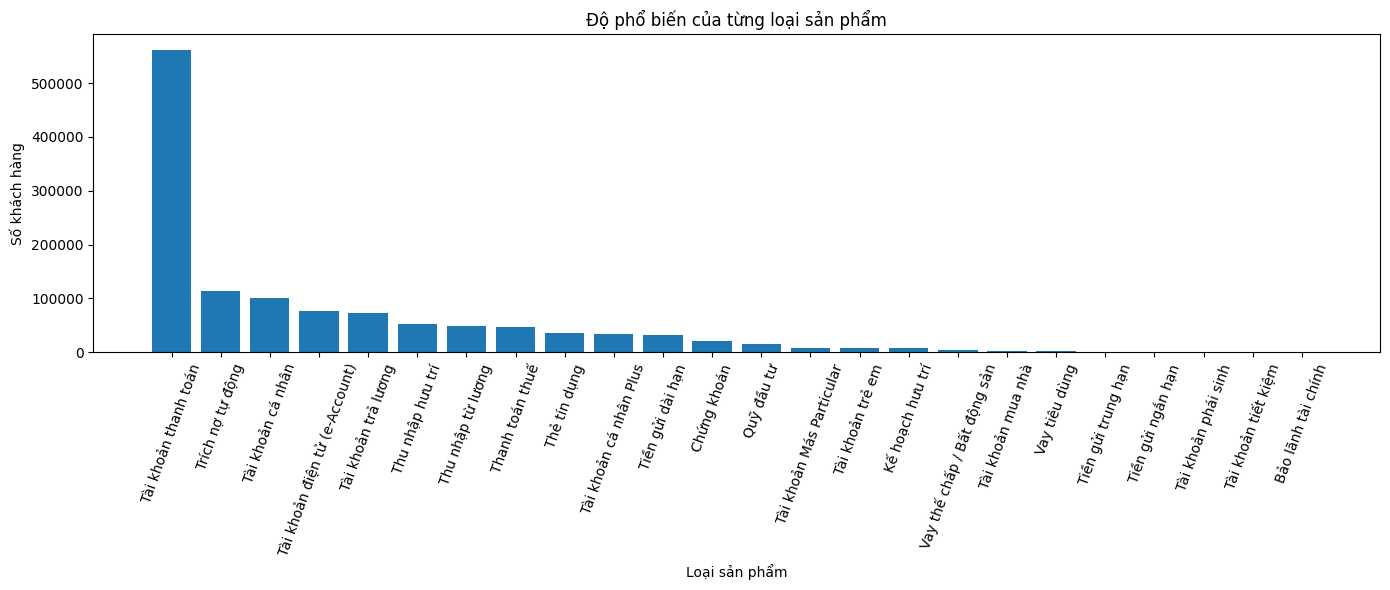

In [22]:
# Độ phổ biến của từng sản phẩm: số khách hàng sở hữu ở snapshot mới nhất.
product_sum_sql = ', '.join(
    f'SUM(COALESCE(TRY_CAST({quote_identifier(column)} AS INTEGER), 0)) AS {quote_identifier(column)}'
    for column in PRODUCT_COLUMNS
)

latest_customer_count = q('''
    SELECT COUNT(DISTINCT ncodpers) AS n
    FROM read_parquet(?)
''', str(TRAIN_PARQUET)).iloc[0, 0]

product_popularity = (
    q(f'''
        WITH latest_snapshot AS (
            SELECT * EXCLUDE (snapshot_rank)
            FROM (
                SELECT *, ROW_NUMBER() OVER (PARTITION BY ncodpers ORDER BY fecha_dato DESC) AS snapshot_rank
                FROM read_parquet(?)
            )
            WHERE snapshot_rank = 1
        )
        SELECT {product_sum_sql} FROM latest_snapshot
    ''', str(TRAIN_PARQUET))
    .T.rename_axis('product_column')
    .reset_index()
    .rename(columns={0: 'customer_count'})
    .assign(
        product=lambda df: df['product_column'].map(PRODUCT_CATALOG).fillna(df['product_column']),
        ratio=lambda df: (df['customer_count'] / latest_customer_count * 100).round(2)
    )
    .sort_values('customer_count', ascending=False)
)

display(product_popularity)
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(product_popularity['product'], product_popularity['customer_count'], color='#1f77b4')
ax.set(title='Độ phổ biến của từng loại sản phẩm', xlabel='Loại sản phẩm', ylabel='Số khách hàng')
ax.tick_params(axis='x', rotation=70)
plt.tight_layout()
plt.show()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_count,customer_count,customer_pct
0,0,256447,26.81
1,1,456390,47.71
2,2,120752,12.62
3,3,47837,5.00
4,4,28777,3.01
5,5,18047,1.89
6,6,12689,1.33
7,7,8356,0.87
8,8,4445,0.46
9,9,1897,0.20


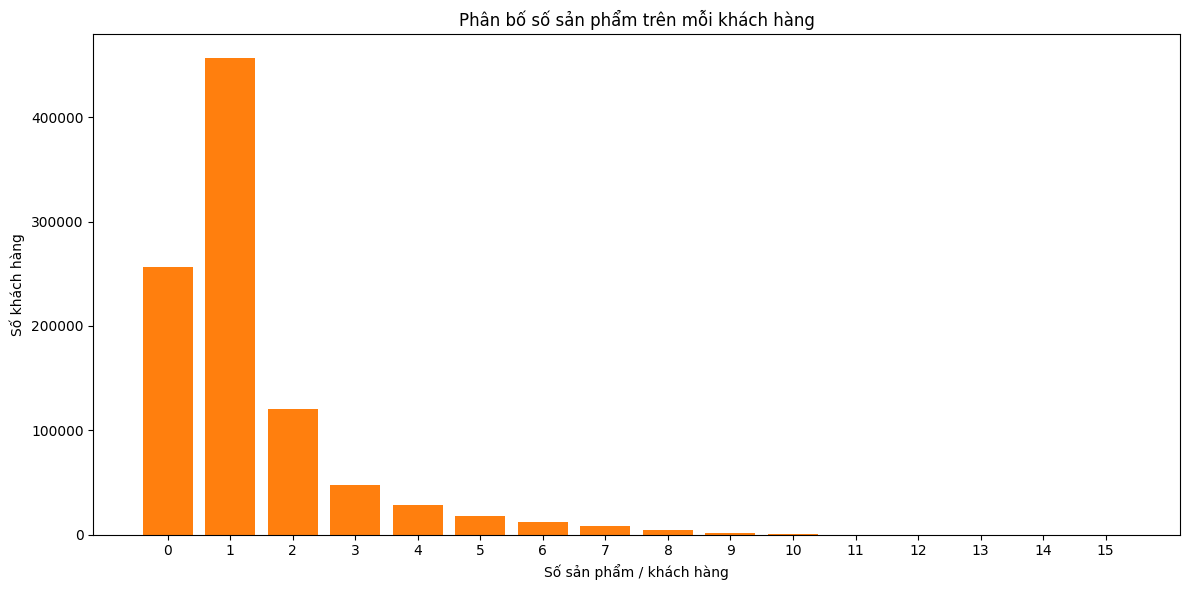

In [21]:
# Phân bố tổng số sản phẩm mà mỗi khách hàng sở hữu ở snapshot mới nhất.
products_per_customer_sql = ' + '.join(
    f'COALESCE(TRY_CAST({quote_identifier(column)} AS INTEGER), 0)'
    for column in PRODUCT_COLUMNS
)

product_count_distribution = q(f'''
    WITH latest_snapshot AS (
        SELECT * EXCLUDE (snapshot_rank)
        FROM (
            SELECT *, ROW_NUMBER() OVER (PARTITION BY ncodpers ORDER BY fecha_dato DESC) AS snapshot_rank
            FROM read_parquet(?)
        )
        WHERE snapshot_rank = 1
    ),
    per_customer AS (
        SELECT {products_per_customer_sql} AS product_count
        FROM latest_snapshot
    )
    SELECT
        product_count,
        COUNT(*) AS customer_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS customer_pct
    FROM per_customer
    GROUP BY product_count
    ORDER BY product_count
''', str(TRAIN_PARQUET))

display(product_count_distribution)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(product_count_distribution['product_count'], product_count_distribution['customer_count'], color='#ff7f0e')
ax.set(
    title='Phân bố số sản phẩm trên mỗi khách hàng',
    xlabel='Số sản phẩm / khách hàng',
    ylabel='Số khách hàng',
)
ax.set_xticks(product_count_distribution['product_count'])
plt.tight_layout()
plt.show()


## 6. Split and leakage checks
Compare train and test schemas, identifiers, time ranges, common numeric distributions, and unseen category values to flag split mismatch or potential leakage.

In [ ]:
if TEST_COLUMNS is None:
    print('Test checkpoint is unavailable; train/test comparison skipped.')
else:
    train_schema = TRAIN_COLUMNS[['column_name', 'column_type']].rename(columns={'column_type': 'train_type'})
    test_schema = TEST_COLUMNS[['column_name', 'column_type']].rename(columns={'column_type': 'test_type'})
    schema_comparison = train_schema.merge(test_schema, on='column_name', how='outer', indicator=True)
    display(schema_comparison.sort_values(['_merge', 'column_name']))
    print('Train-only columns are normally product-state columns. Any other train-only field needs review.')

    common_numeric = [c for c in numeric_features if c in set(TEST_COLUMNS.column_name)]
    numeric_shift_rows = []
    for column in common_numeric:
        col = quote_identifier(column)
        train_stats = q(f'SELECT AVG({col}) AS mean, quantile_cont({col}, 0.5) AS median, COUNT({col}) AS non_null FROM read_parquet(?)', str(TRAIN_PARQUET)).iloc[0].to_dict()
        test_stats = q(f'SELECT AVG({col}) AS mean, quantile_cont({col}, 0.5) AS median, COUNT({col}) AS non_null FROM read_parquet(?)', str(TEST_PARQUET)).iloc[0].to_dict()
        numeric_shift_rows.append({'feature': column, **{f'train_{k}': v for k, v in train_stats.items()}, **{f'test_{k}': v for k, v in test_stats.items()}})
    display(pd.DataFrame(numeric_shift_rows))

    if 'ncodpers' in set(TEST_COLUMNS.column_name):
        display(q('''
            SELECT COUNT(*) AS overlapping_customer_ids
            FROM (SELECT DISTINCT ncodpers FROM read_parquet(?)) train_ids
            INNER JOIN (SELECT DISTINCT ncodpers FROM read_parquet(?)) test_ids USING (ncodpers)
        ''', str(TRAIN_PARQUET), str(TEST_PARQUET)))

    if 'fecha_dato' in set(TEST_COLUMNS.column_name):
        display(q("SELECT 'train' AS split, MIN(fecha_dato) AS min_date, MAX(fecha_dato) AS max_date FROM read_parquet(?) UNION ALL SELECT 'test', MIN(fecha_dato), MAX(fecha_dato) FROM read_parquet(?)", str(TRAIN_PARQUET), str(TEST_PARQUET)))

    shared_categories = [c for c in category_columns_to_check if c in set(TEST_COLUMNS.column_name)]
    unseen_category_rows = []
    for column in shared_categories:
        col = quote_identifier(column)
        unseen = q(f'''
            SELECT COUNT(*) AS unseen_test_categories
            FROM (SELECT DISTINCT {col} FROM read_parquet(?) WHERE {col} IS NOT NULL) test_values
            WHERE {col} NOT IN (SELECT DISTINCT {col} FROM read_parquet(?) WHERE {col} IS NOT NULL)
        ''', str(TEST_PARQUET), str(TRAIN_PARQUET)).iloc[0, 0]
        unseen_category_rows.append({'feature': column, 'unseen_test_categories': unseen})
    display(pd.DataFrame(unseen_category_rows))

    leakage_candidates = [c for c in ALL_COLUMNS if c in PRODUCT_COLUMNS or c.startswith('fecha_') or c == 'ult_fec_cli_1t']
    print('Review before modelling: these columns may encode current/future product state or timing:', leakage_candidates)


,column_name,train_type,test_type,_merge
8,ind_ahor_fin_ult1,TINYINT,NaN,left_only
9,ind_aval_fin_ult1,TINYINT,NaN,left_only
10,ind_cco_fin_ult1,TINYINT,NaN,left_only
11,ind_cder_fin_ult1,TINYINT,NaN,left_only
12,ind_cno_fin_ult1,TINYINT,NaN,left_only
13,ind_ctju_fin_ult1,TINYINT,NaN,left_only
14,ind_ctma_fin_ult1,TINYINT,NaN,left_only
15,ind_ctop_fin_ult1,TINYINT,NaN,left_only
16,ind_ctpp_fin_ult1,TINYINT,NaN,left_only
17,ind_deco_fin_ult1,TINYINT,NaN,left_only


Train-only columns are normally product-state columns. Any other train-only field needs review.


,feature,train_mean,train_median,train_non_null,test_mean,test_median,test_non_null
0,age,40.181465,39.0,13619575.0,40.249821,39.000000,929615.0
1,antiguedad,76.591941,50.0,13619575.0,77.728413,55.000000,929615.0
2,renta,134254.318212,101850.0,10852934.0,134087.870565,101490.515625,701650.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,overlapping_customer_ids
0,929615


,split,min_date,max_date
0,train,2015-01-28,2016-05-28
1,test,2016-06-28,2016-06-28


,feature,unseen_test_categories
0,ind_empleado,0
1,pais_residencia,0
2,sexo,0
3,tiprel_1mes,0
4,canal_entrada,0
5,nomprov,0
6,segmento,0


Review before modelling: these columns may encode current/future product state or timing: ['fecha_dato', 'fecha_alta', 'ult_fec_cli_1t', 'ind_ahor_fin_ult1', 'ind_aval_fin_ult1', 'ind_cco_fin_ult1', 'ind_cder_fin_ult1', 'ind_cno_fin_ult1', 'ind_ctju_fin_ult1', 'ind_ctma_fin_ult1', 'ind_ctop_fin_ult1', 'ind_ctpp_fin_ult1', 'ind_deco_fin_ult1', 'ind_deme_fin_ult1', 'ind_dela_fin_ult1', 'ind_ecue_fin_ult1', 'ind_fond_fin_ult1', 'ind_hip_fin_ult1', 'ind_plan_fin_ult1', 'ind_pres_fin_ult1', 'ind_reca_fin_ult1', 'ind_tjcr_fin_ult1', 'ind_valo_fin_ult1', 'ind_viv_fin_ult1', 'ind_nomina_ult1', 'ind_nom_pens_ult1', 'ind_recibo_ult1']
